# Stage 06 — Modelling
Rolling-origin CV inside train (3 folds, 4 validation weeks each) picks the model; test (12 weeks) is scored once at the end.

In [1]:
import sys, os, warnings, json
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../plugins/dslc/skills/dslc/scripts")
import numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from dslc_style import apply_style, SERIES, INK, save
apply_style()
p = pd.read_parquet("data/processed/weekly_panel.parquet")
tr, te = p[p.split == "train"].copy(), p[p.split == "test"].copy()
CAT = ["SITE_NAME", "ARTICLE"]
NUM = ["lag1", "lag2", "lag3", "lag4", "roll4_mean", "roll8_mean", "roll4_std", "expanding_mean", "store_total_lag1", "shelf_life_days", "avg_rate", "woy"]
def wape(y, f): return float(np.abs(y - f).sum() / y.sum())
def bias(y, f): return float((f.sum() - y.sum()) / y.sum())

## Candidates

In [2]:
def lgb_feats(df):
    X = df[CAT + NUM].copy()
    for c in CAT: X[c] = pd.Categorical(X[c], categories=sorted(p[c].unique()))
    return X
class Base:
    def __init__(self, col): self.col = col
    def fit(self, df): return self
    def predict(self, df): return df[self.col].values
class ArticleMean:
    def fit(self, df): self.m = df.groupby("ARTICLE").units.mean(); return self
    def predict(self, df): return df.ARTICLE.map(self.m).fillna(df.units.mean() if False else self.m.mean()).values
class PoisGLM:
    def __init__(self, cols, alpha): self.cols, self.alpha = cols, alpha
    def fit(self, df):
        num = [c for c in self.cols if c in NUM]; cat = [c for c in self.cols if c in CAT]
        self.pipe = make_pipeline(ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore"), cat), ("n", StandardScaler(), num)]),
                                  PoissonRegressor(alpha=self.alpha, max_iter=500))
        self.pipe.fit(df.assign(**{c: np.log1p(df[c]) for c in num if c.startswith(("lag", "roll", "expanding", "store_total"))}), df.units); return self
    def predict(self, df):
        num = [c for c in self.cols if c in NUM]
        return self.pipe.predict(df.assign(**{c: np.log1p(df[c]) for c in num if c.startswith(("lag", "roll", "expanding", "store_total"))}))
class LGB:
    def __init__(self, obj="poisson", leaves=4, n=300, q=None): self.obj, self.leaves, self.n, self.q = obj, leaves, n, q
    def fit(self, df):
        prm = dict(objective=self.obj, num_leaves=self.leaves, learning_rate=0.03, n_estimators=self.n, min_child_samples=60,
                   subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=5, random_state=42, verbose=-1)
        if self.q: prm["alpha"] = self.q
        self.m = lgb.LGBMRegressor(**prm).fit(lgb_feats(df), df.units); return self
    def predict(self, df): return self.m.predict(lgb_feats(df))
cands = {
    "baseline: expanding mean": lambda: Base("expanding_mean"),
    "baseline: 8-week mean": lambda: Base("roll8_mean"),
    "baseline: last week": lambda: Base("lag1"),
    "article mean (train)": lambda: ArticleMean(),
    "Poisson GLM: article": lambda: PoisGLM(["ARTICLE"], 1e-3),
    "Poisson GLM: article+store": lambda: PoisGLM(["ARTICLE", "SITE_NAME"], 1e-3),
    "Poisson GLM: article+lags": lambda: PoisGLM(["ARTICLE", "roll8_mean", "lag1", "expanding_mean"], 1e-2),
    "LightGBM poisson (4 leaves)": lambda: LGB("poisson", 4, 300),
    "LightGBM poisson (8 leaves)": lambda: LGB("poisson", 8, 300),
    "LightGBM L1 (4 leaves)": lambda: LGB("l1", 4, 300),
}

## Rolling-origin CV (train only)

In [3]:
cuts = ["2024-10-07", "2024-11-04", "2024-12-02"]
rows = []
for name, mk in cands.items():
    ws, bs = [], []
    for c in cuts:
        a = tr[tr.week < c]; b = tr[(tr.week >= c) & (tr.week < pd.Timestamp(c) + pd.Timedelta(weeks=4))]
        f = mk().fit(a).predict(b); ws.append(wape(b.units.values, f)); bs.append(bias(b.units.values, f))
    rows.append({"model": name, "cv_wape": np.mean(ws), "cv_sd": np.std(ws), "cv_bias": np.mean(bs)})
cv = pd.DataFrame(rows).sort_values("cv_wape").round(4); print(cv.to_string(index=False))
os.makedirs("reports/tables", exist_ok=True); cv.to_csv("reports/tables/06_cv_results.csv", index=False)

                      model  cv_wape  cv_sd  cv_bias
     LightGBM L1 (4 leaves)   0.4677 0.0084  -0.0419
LightGBM poisson (8 leaves)   0.4700 0.0101   0.0219
LightGBM poisson (4 leaves)   0.4707 0.0110   0.0283
       article mean (train)   0.4713 0.0120   0.0329
       Poisson GLM: article   0.4713 0.0120   0.0329
 Poisson GLM: article+store   0.4715 0.0118   0.0329
  Poisson GLM: article+lags   0.4720 0.0118   0.0341
   baseline: expanding mean   0.4748 0.0096   0.0309
      baseline: 8-week mean   0.4989 0.0082   0.0183
        baseline: last week   0.6530 0.0264   0.0075


## Choose: best CV WAPE; if within 1% (relative) of a simpler model, prefer the simpler one

In [4]:
simple_rank = {n: i for i, n in enumerate(cands)}          # dict order = simplicity order
best = cv.iloc[0]
close = cv[cv.cv_wape <= best.cv_wape * 1.01].copy(); close["r"] = close.model.map(simple_rank)
chosen = close.sort_values("r").iloc[0].model
print("best CV:", best.model, best.cv_wape, "| chosen (simplest within 1%):", chosen)

best CV: LightGBM L1 (4 leaves) 0.4677 | chosen (simplest within 1%): article mean (train)


## Final: refit on all train, score test once, plus quantile intervals

In [5]:
final = cands[chosen]().fit(tr)
ft = final.predict(te)
tab = {"chosen": chosen, "test_wape": wape(te.units.values, ft), "test_bias": bias(te.units.values, ft), "test_mae": float(np.abs(te.units - ft).mean())}
base = {}
for name in ["baseline: expanding mean", "baseline: 8-week mean", "baseline: last week", "article mean (train)"]:
    base[name] = wape(te.units.values, cands[name]().fit(tr).predict(te))
tab["baselines_test_wape"] = base
print(json.dumps(tab, indent=1))
# prediction intervals: residual quantiles of the chosen model on CV folds' validation weeks, scaled by prediction size
res = []
for c in cuts:
    a = tr[tr.week < c]; b = tr[(tr.week >= c) & (tr.week < pd.Timestamp(c) + pd.Timedelta(weeks=4))]
    m = cands[chosen]().fit(a); res.append(pd.DataFrame({"f": m.predict(b), "y": b.units.values}))
res = pd.concat(res); res["ratio"] = res.y / res.f.clip(lower=0.5)
q = res.ratio.quantile([0.1, 0.5, 0.8, 0.9]).to_dict(); print("ratio quantiles", {k: round(v, 3) for k, v in q.items()})
te["pred"] = ft; te["p10"] = ft * q[0.1]; te["p80"] = ft * q[0.8]; te["p90"] = ft * q[0.9]
tab["coverage_p10_p90"] = float(((te.units >= te.p10) & (te.units <= te.p90)).mean())
tab["p80_service_level"] = float((te.units <= te.p80).mean())
print("P10-P90 coverage (nominal 0.80):", round(tab["coverage_p10_p90"], 3), "| share of weeks demand <= P80 (nominal 0.80):", round(tab["p80_service_level"], 3))
# paired bootstrap of WAPE difference vs best baseline (resample store x article series)
bname = "baseline: expanding mean"; fb = cands[bname]().fit(tr).predict(te)
rng = np.random.default_rng(42); keys = te.groupby(CAT).ngroup().values; K = keys.max() + 1
d = []
for _ in range(1000):
    s = rng.integers(0, K, K); m = np.concatenate([np.where(keys == k)[0] for k in s])
    y = te.units.values[m]; d.append(wape(y, ft[m]) - wape(y, fb[m]))
tab["wape_diff_vs_best_baseline"] = {"baseline": bname, "mean": float(np.mean(d)), "ci95": [float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))]}
print("WAPE diff (model - best baseline) mean, 95% CI:", round(np.mean(d), 4), np.percentile(d, [2.5, 97.5]).round(4))
by = te.assign(ae=(te.units - ft).abs()).groupby("division").agg(units=("units", "sum"), ae=("ae", "sum")); print("WAPE by division:", (by.ae / by.units).round(3).to_dict())
os.makedirs("models", exist_ok=True); final.m.rename("mean_weekly_units_per_store").round(4).to_csv("models/article_means.csv")   # plain-file model: loadable anywhere
json.dump({**tab, "ratio_quantiles": {str(k): v for k, v in q.items()}}, open("models/final_metrics.json", "w"), indent=1, default=float)
te[["SITE_NAME", "ARTICLE", "week", "units", "pred", "p10", "p80", "p90"]].to_csv("reports/tables/06_test_predictions.csv", index=False)

{
 "chosen": "article mean (train)",
 "test_wape": 0.43902816465490563,
 "test_bias": -0.010990124082046087,
 "test_mae": 4.981960408684547,
 "baselines_test_wape": {
  "baseline: expanding mean": 0.4431808403246398,
  "baseline: 8-week mean": 0.4602874145353254,
  "baseline: last week": 0.6172701949860724,
  "article mean (train)": 0.43902816465490563
 }
}
ratio quantiles {0.1: 0.141, 0.5: 0.889, 0.8: 1.476, 0.9: 1.822}
P10-P90 coverage (nominal 0.80): 0.806 | share of weeks demand <= P80 (nominal 0.80): 0.79


WAPE diff (model - best baseline) mean, 95% CI: -0.0042 [-0.0085  0.0001]
WAPE by division: {'Dairy & Milk': 0.499, 'Fruits': 0.44, 'Vegetables': 0.408}


'figures/06_test_total.png'

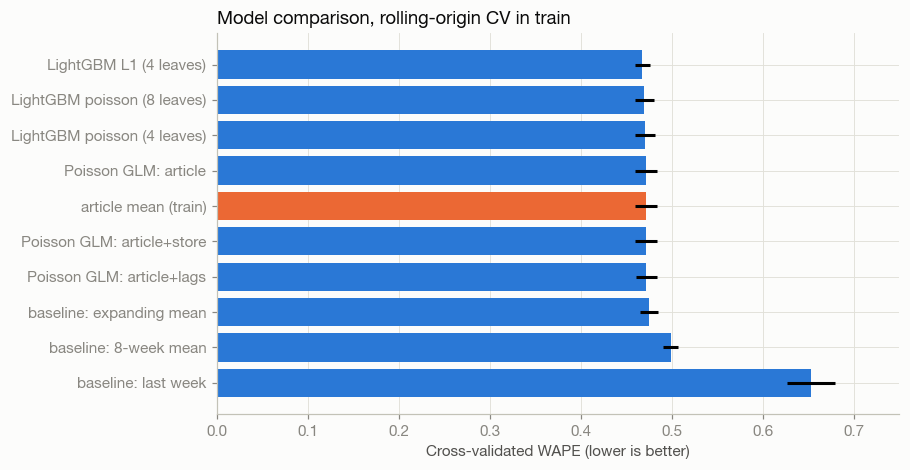

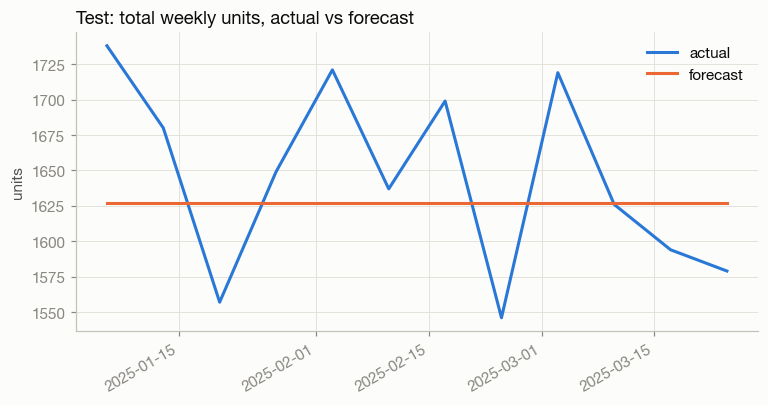

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
lab = cv.sort_values("cv_wape", ascending=False)
ax.barh(lab.model, lab.cv_wape, color=[SERIES[1] if m == chosen else SERIES[0] for m in lab.model], xerr=lab.cv_sd)
ax.set_xlabel("Cross-validated WAPE (lower is better)"); ax.set_title("Model comparison, rolling-origin CV in train"); ax.set_xlim(0, 0.75)
save(fig, "06_cv")
wk = te.groupby("week")[["units", "pred", "p10", "p90"]].sum()
fig, ax = plt.subplots(figsize=(8, 4)); ax.plot(wk.index, wk.units, color=SERIES[0], label="actual"); ax.plot(wk.index, wk.pred, color=SERIES[1], label="forecast")
ax.set_title("Test: total weekly units, actual vs forecast"); ax.set_ylabel("units"); ax.legend(frameon=False); fig.autofmt_xdate(); save(fig, "06_test_total")